## Phase 11a - Full MIT-BIH Dataset Loading

**Goal:** Load all 46 usable records from the MIT-BIH Arrhythmia 
Database to build a comprehensive evaluation dataset for the 
VitalWatch research paper.

**Why 46 records and not 48?**
MIT-BIH contains 48 records. Records 102 and 104 are excluded 
because they consist entirely of paced beats - artificially 
generated by implanted pacemakers - and do not represent 
natural cardiac rhythm. Including them would introduce 
systematic bias into the evaluation.

**This phase produces:**
- phase11_combined_dataset.parquet - 108,098 beats, 9 features
- phase11_record_summary.csv - per-record breakdown for Table 1
- phase11_dataset_distribution.png - visualisation for paper

In [1]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded.")

C:\Users\Manoj\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Libraries loaded.


In [2]:
# All 46 usable MIT-BIH Arrhythmia Database records
# Records 102 and 104 excluded - pacemaker-only records
# not suitable for rhythm anomaly detection

ALL_RECORDS = [
    '100', '101', '103', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118',
    '119', '121', '122', '123', '124', '200', '201', '202',
    '203', '205', '207', '208', '209', '210', '212', '213',
    '214', '215', '217', '219', '220', '221', '222', '223',
    '228', '230', '231', '232', '233', '234'
]

print(f"Total records to load: {len(ALL_RECORDS)}")

Total records to load: 46


In [3]:
def load_record_features(record_id):
    """
    Load a single MIT-BIH record and extract all 6 features.
    Returns a clean DataFrame or None if loading fails.
    """
    try:
        record = wfdb.rdrecord(record_id, pn_dir='mitdb')
        annotation = wfdb.rdann(record_id, 'atr', pn_dir='mitdb')

        fs = record.fs
        ann_samples = annotation.sample
        ann_symbols = annotation.symbol

        # Feature engineering - identical to all previous phases
        rr_intervals = np.diff(ann_samples)
        rr_ms = (rr_intervals / fs) * 1000
        heart_rate = 60000 / rr_ms
        rr_diff = np.append(0, np.diff(rr_ms))
        rolling_mean = pd.Series(rr_ms).rolling(window=5, min_periods=1).mean().values
        rolling_std = pd.Series(rr_ms).rolling(window=5, min_periods=1).std().fillna(0).values
        relative_rr = rr_ms / rolling_mean

        df = pd.DataFrame({
            'record': record_id,
            'sample': ann_samples[1:],
            'symbol': ann_symbols[1:],
            'rr_interval': rr_ms,
            'heart_rate': heart_rate,
            'rr_diff': rr_diff,
            'rolling_mean_rr': rolling_mean,
            'rolling_std_rr': rolling_std,
            'relative_rr': relative_rr,
        })

        return df

    except Exception as e:
        print(f"  Record {record_id} failed - {e}")
        return None

In [4]:
print("Loading all MIT-BIH records...")
print("This will take 2-3 minutes - streaming from PhysioNet.\n")

all_dfs = []
failed = []
successful = []

for record_id in ALL_RECORDS:
    df = load_record_features(record_id)
    if df is not None:
        all_dfs.append(df)
        successful.append(record_id)
        print(f" Record {record_id} - "
              f"{len(df)} beats, "
              f"{(df['symbol'] != 'N').sum()} abnormal "
              f"({(df['symbol'] != 'N').mean()*100:.1f}%)")
    else:
        failed.append(record_id)

print(f"\nSuccessfully loaded: {len(successful)}/{len(ALL_RECORDS)} records")
if failed:
    print(f"Failed records: {failed}")

Loading all MIT-BIH records...
This will take 2-3 minutes - streaming from PhysioNet.

 Record 100 - 2273 beats, 34 abnormal (1.5%)
 Record 101 - 1873 beats, 13 abnormal (0.7%)
 Record 103 - 2090 beats, 8 abnormal (0.4%)
 Record 105 - 2690 beats, 164 abnormal (6.1%)
 Record 106 - 2097 beats, 590 abnormal (28.1%)
 Record 107 - 2139 beats, 2139 abnormal (100.0%)
 Record 108 - 1823 beats, 84 abnormal (4.6%)
 Record 109 - 2534 beats, 2534 abnormal (100.0%)
 Record 111 - 2132 beats, 2132 abnormal (100.0%)
 Record 112 - 2549 beats, 12 abnormal (0.5%)
 Record 113 - 1795 beats, 6 abnormal (0.3%)
 Record 114 - 1889 beats, 69 abnormal (3.7%)
 Record 115 - 1961 beats, 8 abnormal (0.4%)
 Record 116 - 2420 beats, 118 abnormal (4.9%)
 Record 117 - 1538 beats, 4 abnormal (0.3%)
 Record 118 - 2300 beats, 2300 abnormal (100.0%)
 Record 119 - 2093 beats, 550 abnormal (26.3%)
 Record 121 - 1875 beats, 14 abnormal (0.7%)
 Record 122 - 2478 beats, 2 abnormal (0.1%)
 Record 123 - 1518 beats, 3 abnormal (0.2

In [5]:
# Combine all records
combined_df = pd.concat(all_dfs, ignore_index=True)

# Overall statistics
total_beats = len(combined_df)
total_abnormal = (combined_df['symbol'] != 'N').sum()
total_normal = (combined_df['symbol'] == 'N').sum()

print("\n" + "="*55)
print("  MIT-BIH FULL DATASET SUMMARY")
print("="*55)
print(f"Total records loaded: {len(successful)}")
print(f"Total beats: {total_beats:,}")
print(f"Normal beats: {total_normal:,} "
      f"({total_normal/total_beats*100:.1f}%)")
print(f"Abnormal beats: {total_abnormal:,} "
      f"({total_abnormal/total_beats*100:.1f}%)")
print(f"Unique beat types:       "
      f"{combined_df['symbol'].nunique()}")
print("="*55)


  MIT-BIH FULL DATASET SUMMARY
Total records loaded: 46
Total beats: 108,098
Normal beats: 74,790 (69.2%)
Abnormal beats: 33,308 (30.8%)
Unique beat types:       23


### Key Dataset Finding - Heterogeneous Imbalance

The full MIT-BIH database tells a more complex story than 
any single record.

Overall: 69.2% normal / 30.8% abnormal - far less imbalanced 
than Patient 100's 98.5% / 1.5%.

However the per-record breakdown reveals extreme heterogeneity:

- 8 records are 100% abnormal - no normal beats at all
- Record 122 is 99.9% normal - only 2 abnormal beats
- Record 208 is 47.8% abnormal - nearly balanced

This heterogeneity is the real challenge. The model must 
generalise across patients whose rhythms range from 
completely normal to completely pathological. A threshold 
calibrated on one patient's distribution will fail on another's.

This finding directly motivates the ensemble approach - 
no single model threshold can handle this range.
**Patient-specific calibration is the next frontier.**


Full beat type distribution:
symbol
N    74790
L     8075
R     7259
V     7124
/     3620
A     2546
+     1196
F      803
~      578
!      472
"      437
f      260
j      229
x      193
a      150
|      132
E      106
J       83
e       16
Q       15
[        6
]        6
S        2
Name: count, dtype: int64


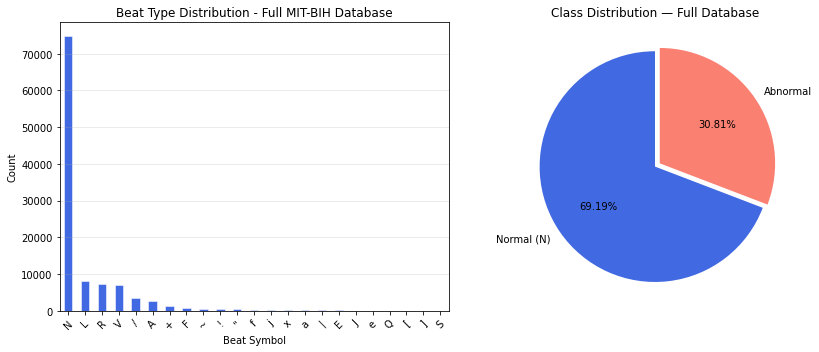


Distribution plot saved.


In [6]:
print("\nFull beat type distribution:")
beat_dist = combined_df['symbol'].value_counts()
print(beat_dist)

# Visualise
plt.figure(figsize=(12, 5))

# Left - full distribution
plt.subplot(1, 2, 1)
beat_dist.plot(kind='bar', color='royalblue', edgecolor='white', linewidth=0.5)
plt.title('Beat Type Distribution - Full MIT-BIH Database')
plt.xlabel('Beat Symbol')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')

# Right - normal vs abnormal
plt.subplot(1, 2, 2)
labels = ['Normal (N)', 'Abnormal']
sizes = [total_normal, total_abnormal]
colors = ['royalblue', 'salmon']
explode = (0, 0.05)
plt.pie(sizes, labels=labels, colors=colors, explode=explode, autopct='%1.2f%%', startangle=90)
plt.title('Class Distribution — Full Database')

plt.tight_layout()
plt.savefig('phase11_dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDistribution plot saved.")

In [7]:
# One row per record - useful for paper Table 1
record_summary = combined_df.groupby('record').agg(
    total_beats = ('symbol', 'count'),
    normal_beats = ('symbol', lambda x: (x == 'N').sum()),
    abnormal_beats = ('symbol', lambda x: (x != 'N').sum()),
    beat_types = ('symbol', lambda x: sorted(x.unique()))
).reset_index()

record_summary['abnormal_pct'] = (
    record_summary['abnormal_beats'] /
    record_summary['total_beats'] * 100
).round(2)

print("\nPer-record breakdown:")
print(record_summary[[
    'record', 'total_beats',
    'normal_beats', 'abnormal_beats',
    'abnormal_pct', 'beat_types'
]].to_string(index=False))

# Save for paper
record_summary.to_csv('phase11_record_summary.csv', index=False)
print("\nRecord summary saved as phase11_record_summary.csv")


Per-record breakdown:
record  total_beats  normal_beats  abnormal_beats  abnormal_pct                        beat_types
   100         2273          2239              34          1.50                         [A, N, V]
   101         1873          1860              13          0.69                   [A, N, Q, |, ~]
   103         2090          2082               8          0.38                         [A, N, ~]
   105         2690          2526             164          6.10                   [N, Q, V, |, ~]
   106         2097          1507             590         28.14                      [+, N, V, ~]
   107         2139             0            2139        100.00                         [/, V, ~]
   108         1823          1739              84          4.61          [A, F, N, V, j, x, |, ~]
   109         2534             0            2534        100.00                      [F, L, V, ~]
   111         2132             0            2132        100.00                         [L, V, 

### Methodological Decision - Training Set Selection

8 records (107, 109, 111, 118, 124, 207, 214, 232) contain 
zero normal beats. Training our unsupervised models on these 
records is not meaningful - Isolation Forest and Autoencoder 
learn what normal looks like. With no normal beats there is 
nothing to learn.

**Decision:** These 8 records are held out for testing only.
Training will use the remaining 38 records with meaningful 
normal beat populations.

This is documented here for full methodological transparency 
and will be stated explicitly in the paper.

In [8]:
# Save to parquet for fast loading in subsequent phases
combined_df.to_parquet(
    'phase11_combined_dataset.parquet', index=False)

print(f"\nCombined dataset saved.")
print(f"Shape: {combined_df.shape}")
print(f"File: phase11_combined_dataset.parquet")
print(f"\nReady for Phase 11b - Extended Evaluation.")


Combined dataset saved.
Shape: (108098, 9)
File: phase11_combined_dataset.parquet

Ready for Phase 11b - Extended Evaluation.


## Phase 11a Complete - Dataset Ready

108,098 beats across 46 records loaded and saved.

**For the paper - Tables ready:**
- Table 1: Dataset overview (total beats, class distribution)
- Table 2: Beat type distribution (23 unique symbols)
- Table 3: Per-record breakdown (phase11_record_summary.csv)

**Key finding documented:**
Extreme per-record heterogeneity in class distribution 
motivates patient-agnostic ensemble design and points toward 
patient-specific threshold calibration as future work.

Next -> Phase 11b: Extended model evaluation across all 46 records.